In [1]:
!pip install seaborn --upgrade

In [2]:
import pandas as pd

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
print("All imports worked!")

All imports worked!


In [15]:
n_subjects =30
n_trials = 40

rows = []

for subj in range(1, n_subjects +1):
  for condition, rt_mean, error_rate in [
      ('congruent', 650, 0.05),
      ('incongruent', 750, 0.12)
  ]:
      for trial in range(n_trials):
          RT = np.random.normal(rt_mean, 90)
          accuracy = np.random.choice(
              [1,0],
              p=[1-error_rate, error_rate]
          )
          rows.append({
              'subject':    subj,
              'condition':  condition,
              'trial':      trial + 1,
              'RT':         RT,
              'accuracy':   accuracy
          })

df = pd.DataFrame(rows)
print(df.shape)

(2400, 5)


In [16]:
df.head(10)

,subject,condition,trial,RT,accuracy
0,1,congruent,1,694.704274,1
1,1,congruent,2,637.556213,1
2,1,congruent,3,628.926196,1
3,1,congruent,4,628.927674,1
4,1,congruent,5,792.129153,1
5,1,congruent,6,719.069126,0
6,1,congruent,7,607.747305,1
7,1,congruent,8,698.830404,1
8,1,congruent,9,671.776604,1
9,1,congruent,10,477.804778,1


In [17]:
df.dtypes

,0
subject,int64
condition,object
trial,int64
RT,float64
accuracy,int64


In [18]:
df['condition'].value_counts()

,count
condition,
congruent,1200
incongruent,1200


In [19]:
df.describe()

,subject,trial,RT,accuracy
count,2400.000000,2400.000000,2400.000000,2400.000000
mean,15.500000,20.500000,702.251114,0.920833
std,8.657245,11.545802,103.302202,0.270055
min,1.000000,1.000000,378.243906,0.000000
25%,8.000000,10.750000,632.811277,1.000000
50%,15.500000,20.500000,700.243273,1.000000
75%,23.000000,30.250000,774.441870,1.000000
max,30.000000,40.000000,1096.745834,1.000000


In [23]:
df_correct = df[df['accuracy'] == 1].copy()

print(f"Trials before: {len(df)}")
print(f"Trials after removing errors: {len(df_correct)}")

Trials before: 2400
Trials after removing errors: 2210


In [24]:
df_clean = df_correct[
    (df_correct['RT'] > 200) &
    (df_correct ['RT'] <2000)
].copy()

print(f"Trials after RT cleaning: {len(df_clean)}")

Trials after RT cleaning: 2210


In [27]:
subject_means = (
    df_clean
    .groupby(['subject', 'condition'])['RT']
    .mean()
    .reset_index()
    .rename(columns={'RT': 'mean_RT'})
)

print(subject_means.head(10))

   subject    condition     mean_RT
0        1    congruent  648.325055
1        1  incongruent  751.926074
2        2    congruent  646.822172
3        2  incongruent  761.086088
4        3    congruent  664.953832
5        3  incongruent  764.807107
6        4    congruent  654.533420
7        4  incongruent  739.403718
8        5    congruent  649.886012
9        5  incongruent  748.739758


In [29]:
wide = subject_means.pivot(
    index='subject',
    columns='condition',
    values='mean_RT'
)
wide.columns.name = None

print(wide.head())

          congruent  incongruent
subject                         
1        648.325055   751.926074
2        646.822172   761.086088
3        664.953832   764.807107
4        654.533420   739.403718
5        649.886012   748.739758


In [30]:
wide['interference'] = wide['incongruent'] - wide['congruent']

print(f"Average interference effect: {wide['interference'].mean():.1f} ms")

Average interference effect: 101.4 ms


In [32]:
t_stat, p_value = stats.ttest_rel(
    wide['incongruent'],
    wide['congruent']
)

print(f"t = {t_stat:.2f}")
print(f"p = {p_value:.4f}")

if p_value <0.05:
  print("The interference is statistically significant.")
else:
  print("The effect did not reach significance")

t = 26.81
p = 0.0000
The interference is statistically significant.


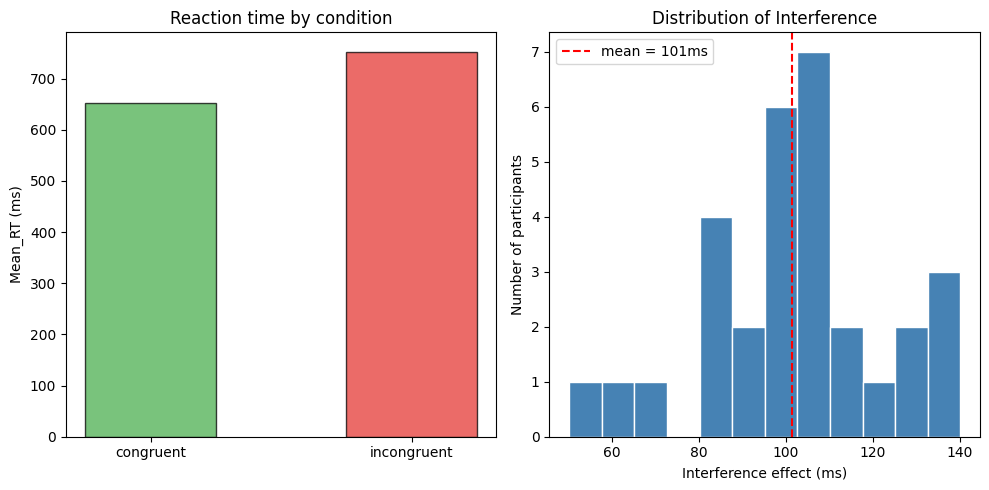

Graph Saved!


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
conditions = ['congruent', 'incongruent']
means = wide[['congruent', 'incongruent']].mean()
colors = ['#4CAF50', '#E53935']

ax.bar(conditions, means, color=colors, alpha=0.75, edgecolor='black', width=0.5)
ax.set_ylabel('Mean_RT (ms)')
ax.set_title('Reaction time by condition')

ax = axes[1]
ax.hist(wide['interference'], bins=12, color='steelblue', edgecolor='white')
ax.axvline(wide['interference'].mean(), color='red', linestyle='--', label=f"mean = {wide['interference'].mean():.0f}ms")
ax.set_xlabel('Interference effect (ms)')
ax.set_ylabel('Number of participants')
ax.set_title('Distribution of Interference')
ax.legend()

plt.tight_layout()
plt.savefig('stroop_result.png', dpi=150)
plt.show()
print("Graph Saved!")